In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ast
from google.colab import drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Define the path based on your script
file_path = '/content/drive/MyDrive/BT4222 Project/Data/Court_Cases.csv'

try:
    # Load the CSV
    # Added encoding='utf-8-sig' to handle potential special characters in legal text
    df = pd.read_csv(file_path, encoding='utf-8-sig')

    print(f"Successfully loaded {len(df)} rows.")

    # Display first few rows to verify headers
    display(df.head())

except Exception as e:
    print(f"Error loading CSV: {e}")

Successfully loaded 358 rows.


,Case_Number,Coram,Judge,Date,Tribunal_Court,Plaintiff_Name,Defendant_Name,Combined_Facts,Issue,Rule,Application,Plaintiff_Label,Defendant_Label
0,CA 206/1999 (Counterclaim),Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-03,Court of Appeal,Gan Boon Hock,Kea Resources Pte Ltd,"[{'Fact_Type': 'CONTRACT_EVENT', 'Fact_Date': ...",Whether an employee is entitled to claim unpai...,An employee may claim financial entitlements i...,He was owed financial entitlements as per his ...,Claim Allowed,Liable
1,CA 206/1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-03,Court of Appeal,Kea Holdings Pte Ltd,Gan Boon Hock,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a director can be held legally respons...,A director must act in the best interests of t...,Gan diverted business and misrepresented sale ...,Claim Allowed In-part,Liable
2,Civil Appeal No 124 of 1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-28,Court of Appeal,Kumagai Property Marketing Pte Ltd,Low Hua Kin,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a subsidiary company can hold its dire...,A director is legally responsible for losses i...,The Plaintiff stated that it was used as a mer...,Claim Allowed,Liable
3,Civil Appeal No 124 of 1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-28,Court of Appeal,Kumagai-Zenecon Construction Pte Ltd (in liqui...,Low Hua Kin,"[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '198...",Whether a joint venture company can recover lo...,A director’s duty to the parent company extend...,The Plaintiff stated that the director’s unaut...,Claim Allowed,Liable
4,Suit 1032/1999,Kan Ting Chiu J,Kan Ting Chiu,2000-08-26,High Court of Singapore,Jurong Readymix Concrete Pte Ltd,Chng Heng Tiu,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a corporate guarantor is liable for un...,A guarantee is enforceable if supported by val...,A concrete supplier increased a contractor's c...,Claim Allowed,Liable


In [8]:
cat_cols = ["Tribunal_Court", "Plaintiff_Label", "Defendant_Label"]
for col in cat_cols:
    print(f"\n--- {col} ---")
    vc = df[col].value_counts()
    print(vc.to_string())

print(f"\n--- Unique Judges ({df['Judge'].nunique()}) ---")
print(df["Judge"].value_counts().head(15).to_string())


--- Tribunal_Court ---
Tribunal_Court
High Court of Singapore                              221
General Division of the High Court of Singapore       89
Court of Appeal                                       42
Singapore International Commercial Court               3
General Division of the High Court                     2
Appellate Division of the High Court of Singapore      1

--- Plaintiff_Label ---
Plaintiff_Label
Claim Dismissed          167
Claim Allowed In-part    108
Claim Allowed             81
Claim Allowed in Part      2

--- Defendant_Label ---
Defendant_Label
Liable        191
Not Liable    167

--- Unique Judges (65) ---
Judge
Mohamed Faizal         24
Tay Yong Kwang         20
Philip Jeyaretnam J    16
Woo Bih Li             16
Tan Lee Meng           15
Audrey Lim J           14
Kannan Ramesh          13
Lai Siu Chiu           12
Judith Prakash         11
Kan Ting Chiu          11
Lai Siu Chiu J         10
Belinda Ang Saw Ean    10
Edmund Leow JC         10
Hri Kumar Nai

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Cases by year:\n{df['Date'].dt.year.value_counts().sort_index().to_string()}")

Date range : 2000-07-03  →  2025-07-29
Cases by year:
Date
2000     6
2001     5
2002     1
2003    42
2004    24
2005     2
2006     8
2007    13
2008     2
2009     3
2010     8
2011     5
2012     5
2013    33
2014    10
2015     5
2016    21
2017    19
2018    14
2019    12
2020    15
2021    15
2022    18
2023     6
2024    39
2025    27


In [13]:
text_cols = ["Combined_Facts", "Issue", "Rule", "Application"]
for col in text_cols:
    lengths = df[col].str.len()
    print(f"\n{col}:")
    print(f"  min={lengths.min():,}  median={lengths.median():,.0f}  "
          f"mean={lengths.mean():,.0f}  max={lengths.max():,}")


Combined_Facts:
  min=283  median=4,032  mean=6,350  max=27,414

Issue:
  min=18  median=214  mean=215  max=478

Rule:
  min=10  median=290  mean=317  max=985

Application:
  min=10.0  median=522  mean=531  max=2,279.0


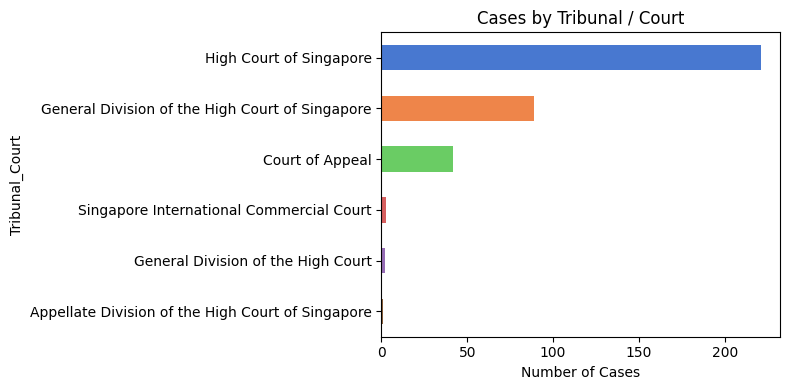

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
vc = df["Tribunal_Court"].value_counts()
vc.plot(kind="barh", ax=ax, color=sns.color_palette("muted", len(vc)))
ax.set_title("Cases by Tribunal / Court")
ax.set_xlabel("Number of Cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

/tmp/ipykernel_10706/3484278599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Defendant_Label', palette='viridis')


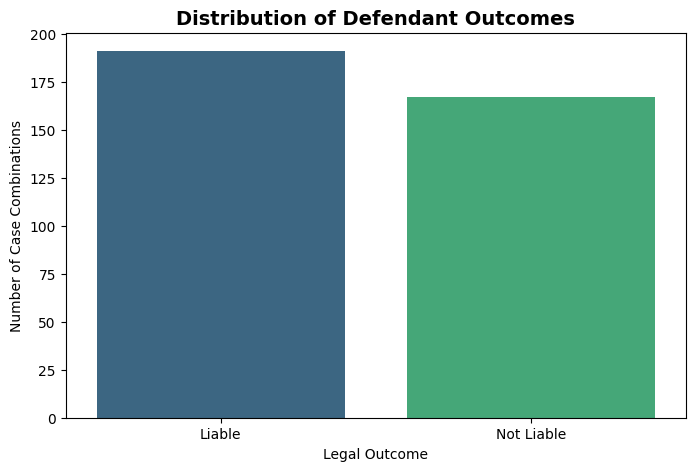

In [16]:
# Distribution of Case Outcomes
plt.figure(figsize=(8, 5))
# Using defendant_label to see how often they are 'Liable' vs 'Not Liable'
sns.countplot(data=df, x='Defendant_Label', palette='viridis')
plt.title('Distribution of Defendant Outcomes', fontsize=14, fontweight='bold')
plt.xlabel('Legal Outcome')
plt.ylabel('Number of Case Combinations')
plt.show()

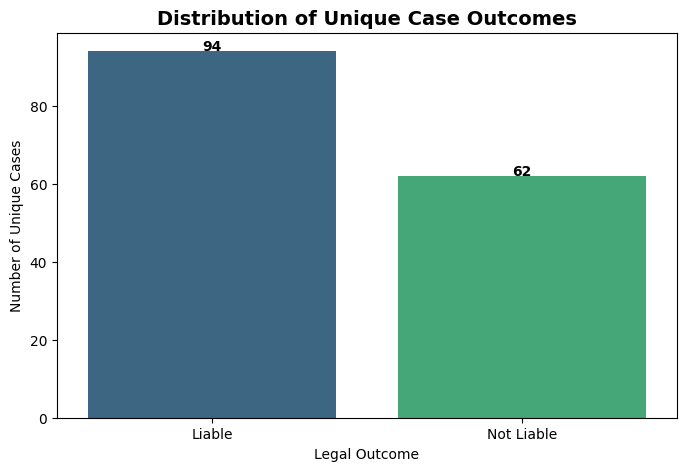

In [17]:
# 1. Group by Case_Number to get the outcome for each unique case
unique_cases = df.groupby('Case_Number')['Defendant_Label'].first().reset_index()

# 2. Plot the Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=unique_cases, x='Defendant_Label', palette='viridis', hue='Defendant_Label', legend=False)

plt.title('Distribution of Unique Case Outcomes', fontsize=14, fontweight='bold')
plt.xlabel('Legal Outcome')
plt.ylabel('Number of Unique Cases')

# Add counts on top of bars for clarity
for i, count in enumerate(unique_cases['Defendant_Label'].value_counts().sort_index()):
    plt.text(i, count + 0.1, str(count), ha='center', fontweight='bold')

plt.show()

In [18]:
# Ensure Date is datetime type for sorting
df['Date'] = pd.to_datetime(df['Date'])

# Group by Case_Number to find the earliest date per case, then sort
cases = df.groupby('Case_Number')['Date'].min().sort_values().reset_index()

# Calculate split indices (70% Train, 15% Val, 15% Test)
n_cases = len(cases)
train_end = int(n_cases * 0.7)
val_end = int(n_cases * 0.85)

# Extract the Case_Numbers for each split
train_case_ids = cases.iloc[:train_end]['Case_Number']
val_case_ids = cases.iloc[train_end:val_end]['Case_Number']
test_case_ids = cases.iloc[val_end:]['Case_Number']

# Map the isolated Case_Numbers back to the main DataFrame
# Using .copy() prevents SettingWithCopy warnings later
train_df = df[df['Case_Number'].isin(train_case_ids)].copy()
val_df = df[df['Case_Number'].isin(val_case_ids)].copy()
test_df = df[df['Case_Number'].isin(test_case_ids)].copy()

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows | Test: {len(test_df)} rows")

Train: 254 rows | Val: 32 rows | Test: 72 rows


In [19]:
target_col = 'Defendant_Label' # Change this if your column has a different name

print("\n" + "="*50)
print("1. LABEL DISTRIBUTION BY ROWS (Individual Defendants)")
print("="*50)
print(f"--- TRAIN SET ({len(train_df)} rows) ---")
print(train_df[target_col].value_counts().to_string())

print(f"\n--- VAL SET ({len(val_df)} rows) ---")
print(val_df[target_col].value_counts().to_string())

print(f"\n--- TEST SET ({len(test_df)} rows) ---")
print(test_df[target_col].value_counts().to_string())


# Define a helper function to determine the "Case-Level" outcome
# Logic: If ANY defendant in a case is Liable, the case involves liability.
def get_case_outcome(labels):
    # Adjust 'Liable' to exactly match the string/number in your dataset (e.g., 1 or 'Liable')
    if 'Liable' in labels.values or 1 in labels.values:
        return 'Liable (At least 1 Defendant)'
    return 'Not Liable (All Defendants)'

print("\n\n" + "="*50)
print("2. LABEL DISTRIBUTION BY CASE (Overall Case Outcome)")
print("="*50)

# Group by Case_Number and apply the helper function
train_case_dist = train_df.groupby('Case_Number')[target_col].agg(get_case_outcome).value_counts()
val_case_dist = val_df.groupby('Case_Number')[target_col].agg(get_case_outcome).value_counts()
test_case_dist = test_df.groupby('Case_Number')[target_col].agg(get_case_outcome).value_counts()

print(f"--- TRAIN SET ({len(train_case_ids)} Cases) ---")
print(train_case_dist.to_string())

print(f"\n--- VAL SET ({len(val_case_ids)} Cases) ---")
print(val_case_dist.to_string())

print(f"\n--- TEST SET ({len(test_case_ids)} Cases) ---")
print(test_case_dist.to_string())


1. LABEL DISTRIBUTION BY ROWS (Individual Defendants)
--- TRAIN SET (254 rows) ---
Defendant_Label
Not Liable    130
Liable        124

--- VAL SET (32 rows) ---
Defendant_Label
Liable        19
Not Liable    13

--- TEST SET (72 rows) ---
Defendant_Label
Liable        48
Not Liable    24


2. LABEL DISTRIBUTION BY CASE (Overall Case Outcome)
--- TRAIN SET (109 Cases) ---
Defendant_Label
Liable (At least 1 Defendant)    71
Not Liable (All Defendants)      38

--- VAL SET (23 Cases) ---
Defendant_Label
Liable (At least 1 Defendant)    14
Not Liable (All Defendants)       9

--- TEST SET (24 Cases) ---
Defendant_Label
Liable (At least 1 Defendant)    16
Not Liable (All Defendants)       8


In [22]:
# 1. Update the timeline dataframe to include the label
case_timeline = all_splits.groupby('Case_Number').agg({
    'Date': 'min',
    'Split': 'first',
    'Defendant_Label': 'first'  # We pull the label into our unique case list
}).reset_index()

# 2. Print the detailed temporal and label breakdown
print("==================================================")
print("       TEMPORAL SPLIT & LABEL DISTRIBUTION")
print("==================================================")

for split in ['Train', 'Val', 'Test']:
    subset = case_timeline[case_timeline['Split'] == split]
    label_counts = subset['Defendant_Label'].value_counts()
    total = len(subset)

    print(f"\n[{split} Split]")
    print(f"Range: {subset['Date'].min().date()} to {subset['Date'].max().date()}")
    print(f"Total Cases: {total}")

    for label, count in label_counts.items():
        pct = (count / total) * 100
        print(f"  - {label:10}: {count} cases ({pct:.1f}%)")
    print("-" * 40)

       TEMPORAL SPLIT & LABEL DISTRIBUTION

[Train Split]
Range: 2000-07-03 to 2021-02-02
Total Cases: 109
  - Liable    : 65 cases (59.6%)
  - Not Liable: 44 cases (40.4%)
----------------------------------------

[Val Split]
Range: 2021-02-02 to 2022-09-26
Total Cases: 23
  - Liable    : 13 cases (56.5%)
  - Not Liable: 10 cases (43.5%)
----------------------------------------

[Test Split]
Range: 2023-05-26 to 2025-07-29
Total Cases: 24
  - Liable    : 16 cases (66.7%)
  - Not Liable: 8 cases (33.3%)
----------------------------------------


In [23]:
for split in ['Train', 'Val', 'Test']:
    subset = case_timeline[case_timeline['Split'] == split]
    print(f"{split} Range: {subset['Date'].min().date()} to {subset['Date'].max().date()} ({len(subset)} cases)")

Train Range: 2000-07-03 to 2021-02-02 (109 cases)
Val Range: 2021-02-02 to 2022-09-26 (23 cases)
Test Range: 2023-05-26 to 2025-07-29 (24 cases)


/tmp/ipykernel_10706/1665784133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Defendant_Label', y='App_WordCount', palette='Set2')


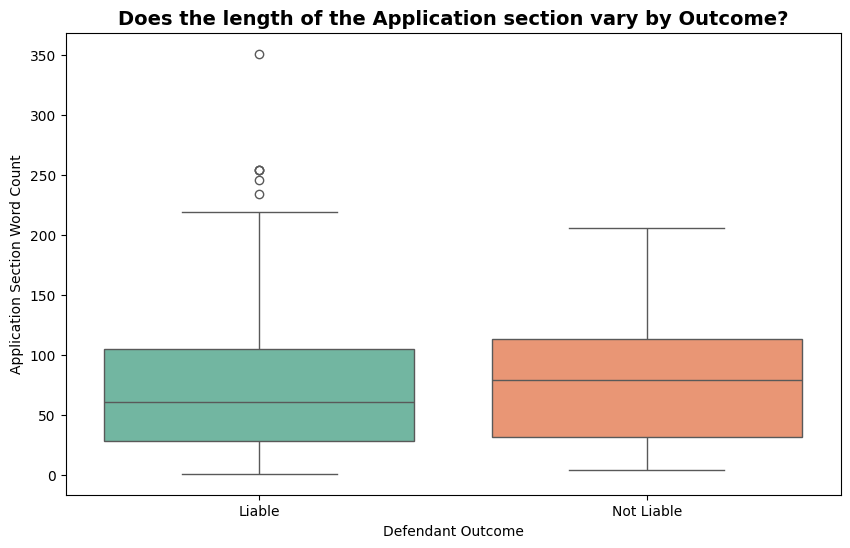

In [27]:
df['App_WordCount'] = df['Application'].str.split().str.len()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Defendant_Label', y='App_WordCount', palette='Set2')
plt.title('Does the length of the Application section vary by Outcome?', fontsize=14, fontweight='bold')
plt.xlabel('Defendant Outcome')
plt.ylabel('Application Section Word Count')
plt.show()

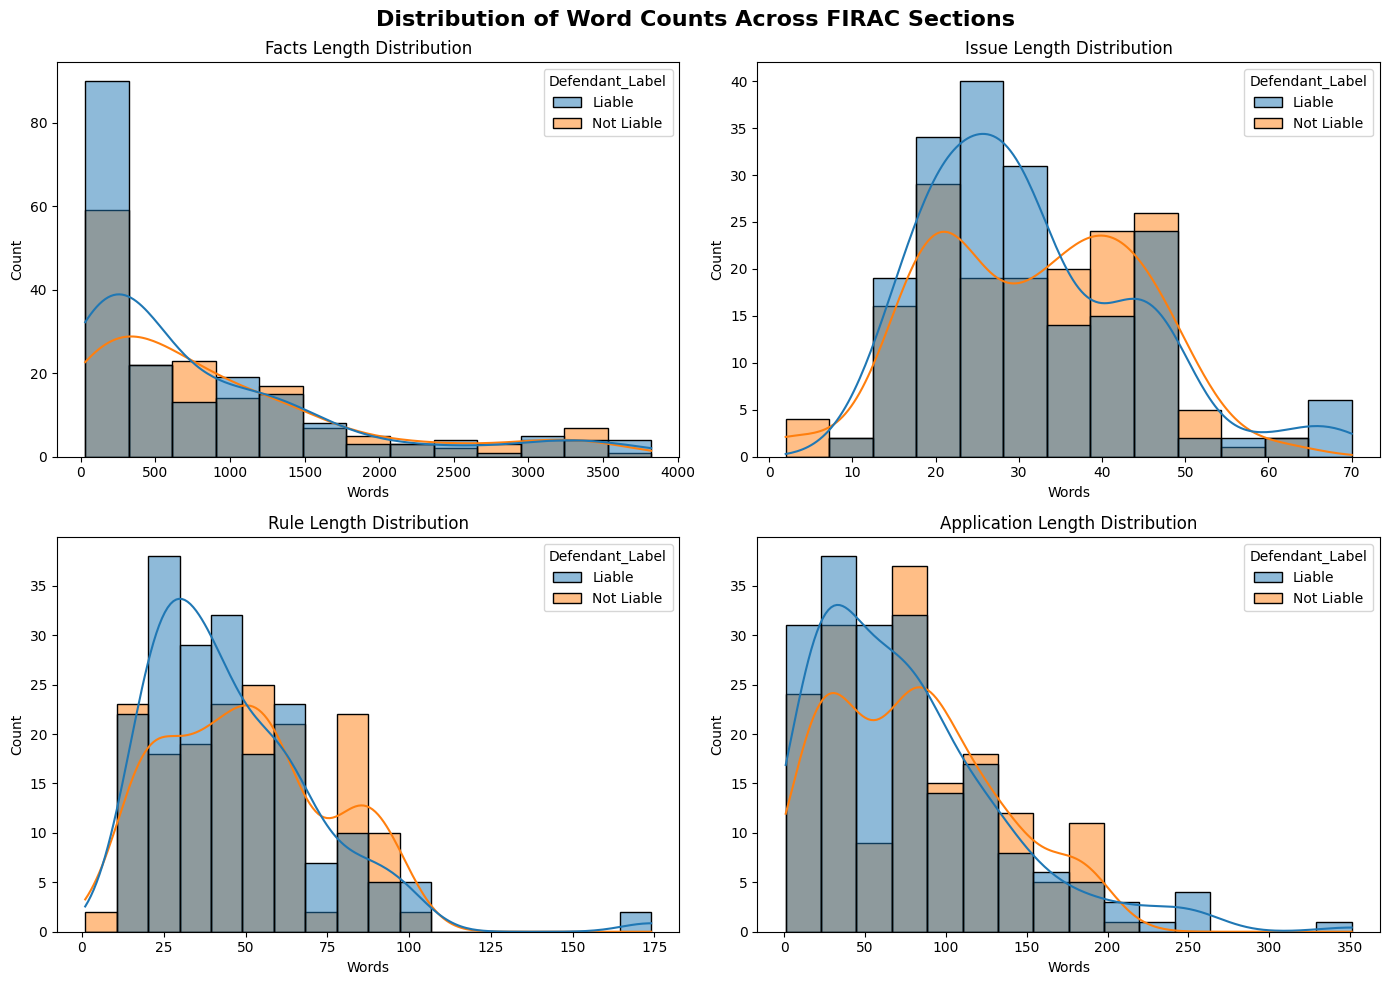

In [43]:
df['Facts_WordCount'] = df['Combined_Facts'].str.split().str.len()
df['Issue_WordCount'] = df['Issue'].str.split().str.len()
df['Rule_WordCount'] = df['Rule'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Word Counts Across FIRAC Sections', fontsize=16, fontweight='bold')

# Plot Facts
sns.histplot(data=df, x='Facts_WordCount', hue='Defendant_Label' , kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Facts Length Distribution')
axes[0, 0].set_xlabel('Words')

# Plot Issue
sns.histplot(data=df, x='Issue_WordCount', hue='Defendant_Label' , kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Issue Length Distribution')
axes[0, 1].set_xlabel('Words')

# Plot Rule
sns.histplot(data=df, x='Rule_WordCount', hue='Defendant_Label' , kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Rule Length Distribution')
axes[1, 0].set_xlabel('Words')

# Plot Application
sns.histplot(data=df, x='App_WordCount', hue='Defendant_Label' , kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Application Length Distribution')
axes[1, 1].set_xlabel('Words')

plt.tight_layout()
plt.show()

--- Tabular Breakdown ---
          Fact_Type Outcome_Label  Count
            CONDUCT        Liable   1437
            CONDUCT    Not Liable   1192
    FINANCIAL_EVENT        Liable   1035
    FINANCIAL_EVENT    Not Liable    867
     CONTRACT_EVENT    Not Liable    619
      COMMUNICATION    Not Liable    518
     CONTRACT_EVENT        Liable    501
     CORPORATE_ROLE        Liable    466
      COMMUNICATION        Liable    446
     CORPORATE_ROLE    Not Liable    357
           DOCUMENT        Liable    321
         PARTY_INFO        Liable    276
       BOARD_ACTION    Not Liable    274
           DOCUMENT    Not Liable    271
         PARTY_INFO    Not Liable    248
       RELATIONSHIP        Liable    164
       RELATIONSHIP    Not Liable    162
       BOARD_ACTION        Liable    137
RELATED_PARTY_EVENT        Liable     80
RELATED_PARTY_EVENT    Not Liable     47
         CHRONOLOGY        Liable     24
         CHRONOLOGY    Not Liable      7
    AUTHORITY_EVENT    Not Liab

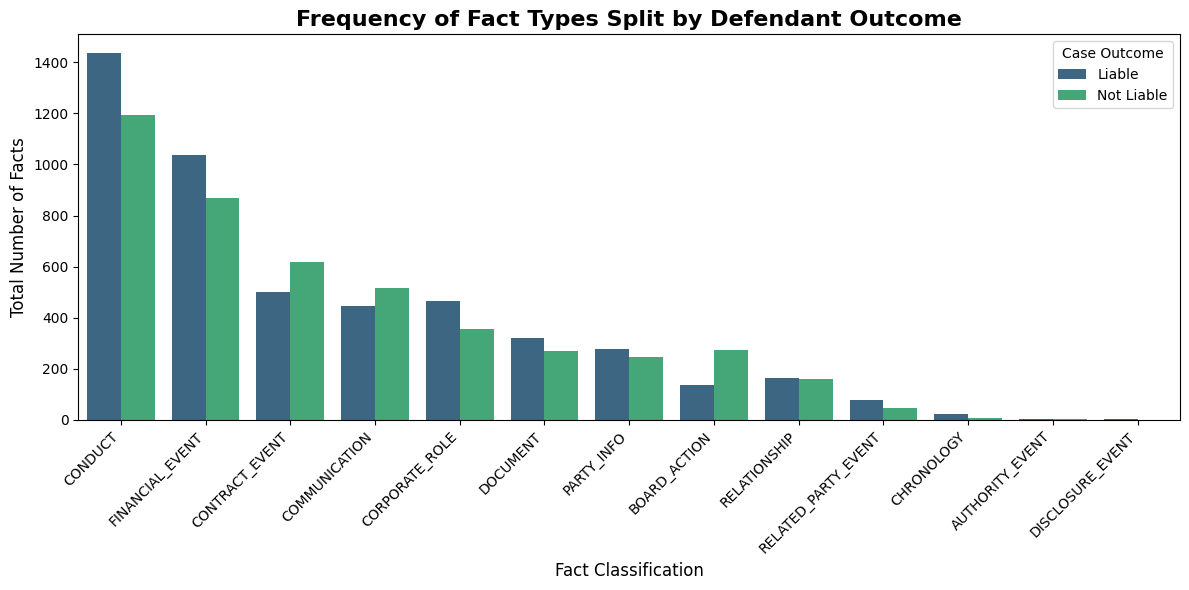

In [35]:
# 1. Create a master list to hold our unpacked facts
extracted_facts = []

# 2. Iterate through every row in your flattened DataFrame
for index, row in df.iterrows():
    # Let's split by the defendant's label (you can change this to plaintiff_label)
    outcome_label = row['Defendant_Label']

    cell = row['Combined_Facts']

    # Safely evaluate if the data was stringified by a CSV export
    if isinstance(cell, str):
        try:
            cell = ast.literal_eval(cell)
        except (ValueError, SyntaxError):
            continue

    # cell is expected to be: a list of fact dictionaries
    if isinstance(cell, list):
        for fact in cell: # Directly iterate over fact dictionaries
            # Look for the dictionaries that contain the actual fact data
            if isinstance(fact, dict) and 'Fact_Type' in fact:
                extracted_facts.append({
                    'Fact_Type': fact['Fact_Type'],
                    'Outcome_Label': outcome_label
                })

# 3. Convert the list of dictionaries into a new Pandas DataFrame
df_facts_expanded = pd.DataFrame(extracted_facts)

# 4. Group by the Fact_Type and the Outcome_Label to get the counts
fact_counts = df_facts_expanded.groupby(['Fact_Type', 'Outcome_Label']).size().reset_index(name='Count')

# Sort it so it looks nice in the printout
fact_counts = fact_counts.sort_values(by=['Count'], ascending=False)
print("--- Tabular Breakdown ---")
print(fact_counts.to_string(index=False))

# 5. Visualize it!
plt.figure(figsize=(12, 6))

# Use seaborn's grouped bar chart functionality via the 'hue' parameter
sns.barplot(
    data=fact_counts,
    x='Fact_Type',
    y='Count',
    hue='Outcome_Label',
    palette='viridis'
)

plt.title('Frequency of Fact Types Split by Defendant Outcome', fontsize=16, fontweight='bold')
plt.xlabel('Fact Classification', fontsize=12)
plt.ylabel('Total Number of Facts', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.legend(title='Case Outcome')
plt.tight_layout()
plt.show()

--- Tabular Data: Outcomes by P:D Ratio ---
P:D Ratio Defendant_Label  Total Combinations
      1:1          Liable                  53
      1:1      Not Liable                  28
     1:10          Liable                   2
     1:10      Not Liable                   8
      1:2          Liable                  36
      1:2      Not Liable                  28
      1:3          Liable                  21
      1:3      Not Liable                  21
      1:4          Liable                  10
      1:4      Not Liable                   6
      1:5          Liable                   4
      1:5      Not Liable                  11
      1:6          Liable                  13
      1:6      Not Liable                  11
      1:7      Not Liable                   7
      1:9      Not Liable                   9
      2:1          Liable                   5
      2:1      Not Liable                   3
      2:2          Liable                   8
      2:2      Not Liable           

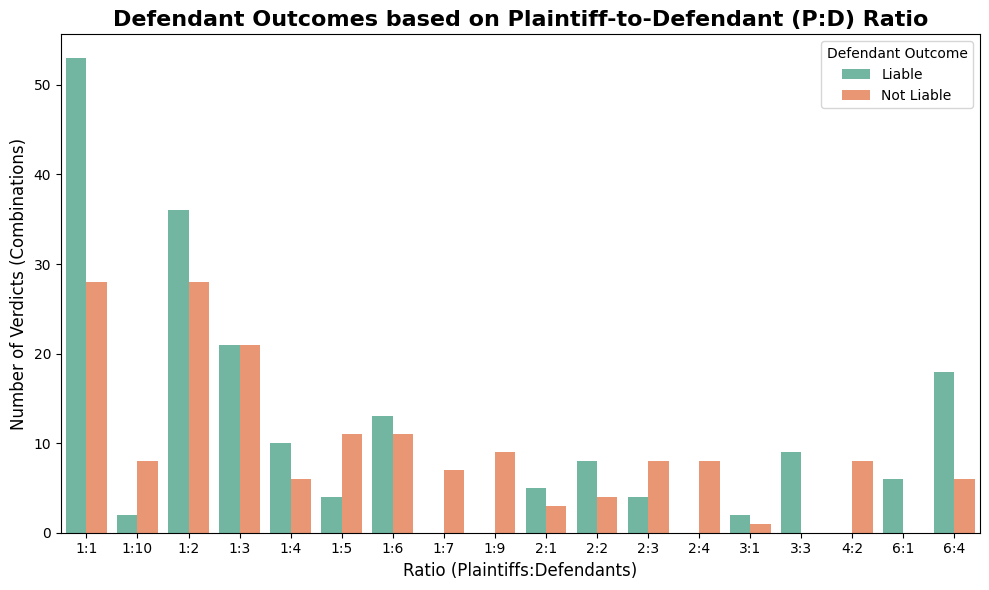

In [38]:
# 1. Calculate the number of unique Plaintiffs and Defendants per Case
case_summary = df.groupby('Case_Number').agg(
    Num_Plaintiffs=('Plaintiff_Name', 'nunique'),
    Num_Defendants=('Defendant_Name', 'nunique')
).reset_index()

# 2. Create the numerical ratio string (e.g., "3:1" instead of "3P : 1D")
case_summary['P:D Ratio'] = case_summary['Num_Plaintiffs'].astype(str) + ":" + case_summary['Num_Defendants'].astype(str)

# 3. Merge this ratio back into our main working DataFrame
if 'P:D Ratio' in df.columns:
    df = df.drop(columns=['P:D Ratio']) # Drop if it already exists from a previous run
df = df.merge(case_summary[['Case_Number', 'P:D Ratio']], on='Case_Number', how='left')

# 4. Group by the Ratio and the Outcome Label to count them
ratio_outcome_counts = df.groupby(['P:D Ratio', 'Defendant_Label']).size().reset_index(name='Total Combinations')

print("--- Tabular Data: Outcomes by P:D Ratio ---")
print(ratio_outcome_counts.to_string(index=False))
print("\n")

# 5. Visualize it!
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ratio_outcome_counts,
    x='P:D Ratio',
    y='Total Combinations',
    hue='Defendant_Label',
    palette='Set2'
)

plt.title('Defendant Outcomes based on Plaintiff-to-Defendant (P:D) Ratio', fontsize=16, fontweight='bold')
plt.xlabel('Ratio (Plaintiffs:Defendants)', fontsize=12)
plt.ylabel('Number of Verdicts (Combinations)', fontsize=12)
plt.legend(title='Defendant Outcome')
plt.tight_layout()
plt.show()

Extracting text using fast regex method...
Text extraction complete!


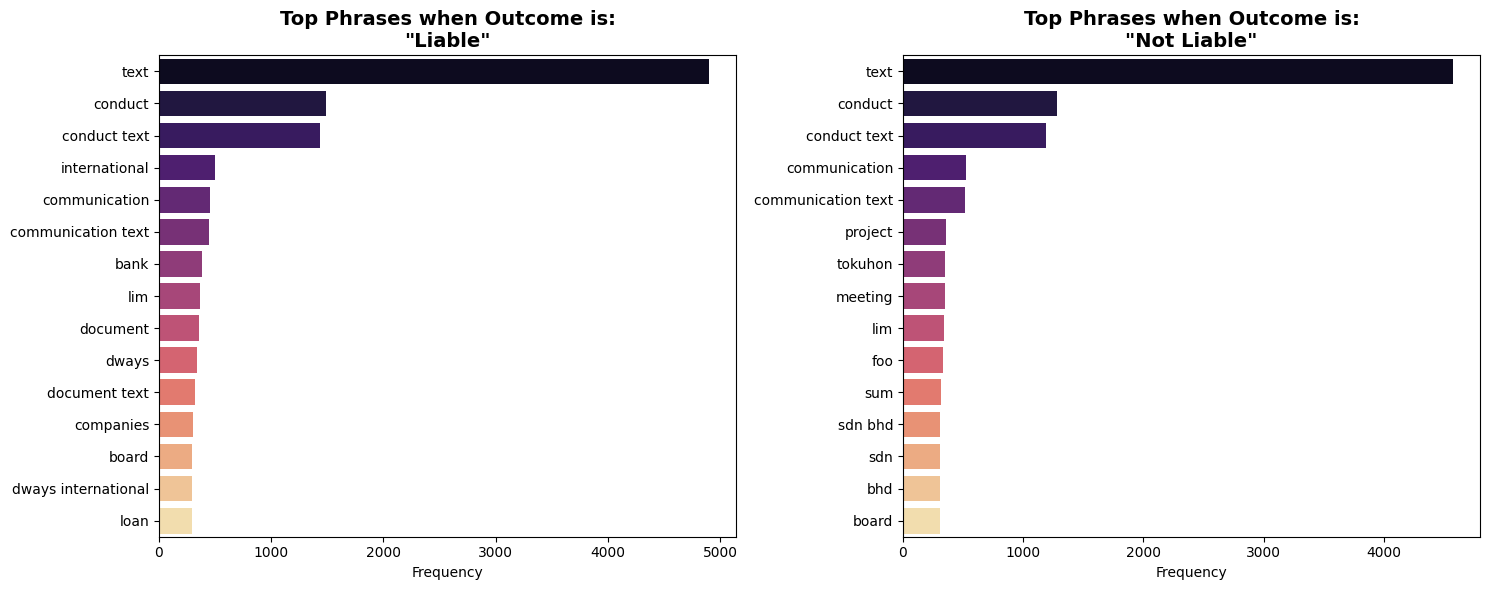

In [41]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

def fast_extract_text(row):
    text_blocks = []
    for col in ['Combined_Facts', 'Issue', 'Rule', 'Application']:
        cell = str(row[col])

        dict_texts = re.findall(r"['\"]Text['\"]\s*:\s*['\"](.*?)['\"](?=\s*[,]})", cell)

        if dict_texts:
            text_blocks.extend(dict_texts)
        else:
            # Corrected regex for the FutureWarning: escape square brackets
            clean_text = re.sub(r"[\[\]{}'\"]", " ", cell)
            text_blocks.append(clean_text)

    return " ".join(text_blocks)

print("Extracting text using fast regex method...")
df['Full_Case_Text'] = df.apply(fast_extract_text, axis=1)
print("Text extraction complete!")

months = [
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december'
]

# Existing legal boilerplate words
custom_legal_stopwords = [
    'pte', 'ltd', 'company', 'plaintiff', 'defendant', 'director', 'directors',
    'mr', 'ms', 'group', 'limited', 'singapore', 'holdings', 'shares',
    'account', 'business', 'agreement', 'management', 'court', 'case', 'claim',
    'said', 'stated'
]

# Combine English stop words + legal words + months
all_stop_words = list(ENGLISH_STOP_WORDS) + custom_legal_stopwords + months

# The token_pattern still strictly enforces letters only (no numbers)
vectorizer = CountVectorizer(
    stop_words=all_stop_words,
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)

outcomes = df['Defendant_Label'].dropna().unique()

fig, axes = plt.subplots(1, len(outcomes), figsize=(15, 6), sharey=False)
if len(outcomes) == 1:
    axes = [axes] # Failsafe if there is only 1 outcome

for i, outcome in enumerate(outcomes):
    subset_text = df[df['Defendant_Label'] == outcome]['Full_Case_Text']

    if subset_text.empty:
        continue

    word_counts = vectorizer.fit_transform(subset_text)
    words = vectorizer.get_feature_names_out()
    counts = word_counts.sum(axis=0).A1

    df_words = pd.DataFrame({'Word': words, 'Count': counts})
    df_words = df_words.sort_values('Count', ascending=False).head(15)

    # Plot: Added hue and legend=False to address FutureWarning
    sns.barplot(data=df_words, x='Count', y='Word', hue='Word', ax=axes[i], palette='magma', legend=False)
    axes[i].set_title(f'Top Phrases when Outcome is:\n"{outcome}"', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()